In [1]:
from google.colab import files

uploaded = files.upload()

Saving Wine dataset.csv to Wine dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("Wine dataset.csv")

print(df.head())
print(df.shape)

   class  Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315 of diluted wines  Proline   
0             5.64  1.04                          3.92      1065  
1             4.38  1.05

In [5]:
# Separate features and target

X = df.drop("class", axis=1)
y = df["class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (178, 13)
Target shape: (178,)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

PCA shape: (178, 2)
Explained variance: [0.36198848 0.1920749 ]
Total explained variance: 0.5540633835693527


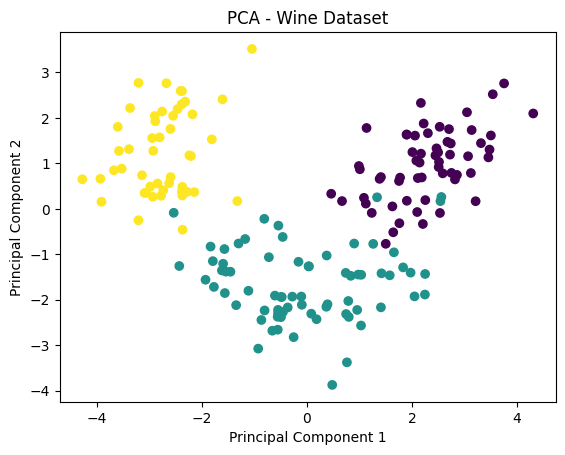

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Wine Dataset")
plt.show()


In [9]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE shape:", X_tsne.shape)

t-SNE shape: (178, 2)


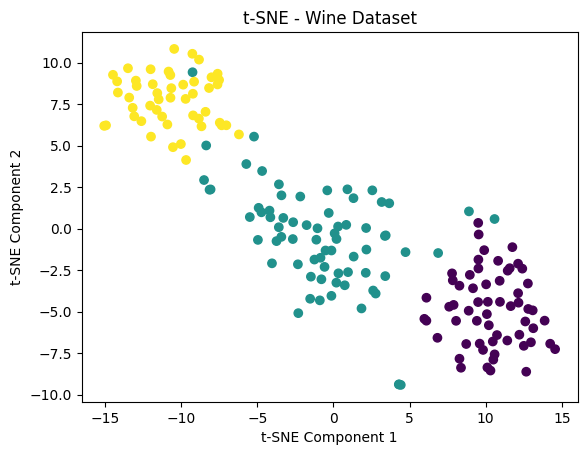

In [10]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE - Wine Dataset")
plt.show()